In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
X, y_true = make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)

In [3]:
df = pd.DataFrame(X, columns=['Feature_1','Feature_2'])
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
inertia = []
K_range = range(1,11)

In [6]:
for k in K_range:
    kmeans =KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [7]:
inertia

[1000.0,
 297.8954141051722,
 11.57548472310498,
 9.752067977356841,
 8.25717527244628,
 6.9175773204167985,
 6.334755391595287,
 5.70417717790143,
 5.060234133532076,
 4.762361898130397]

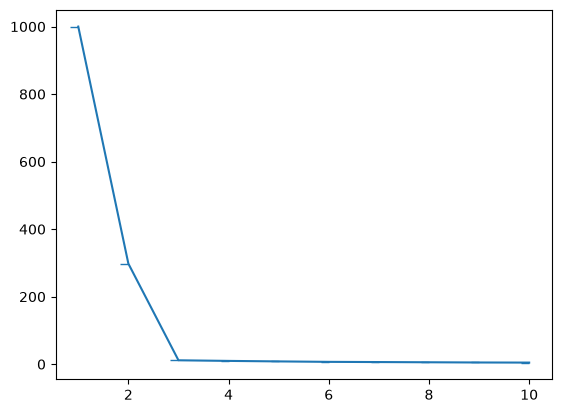

In [8]:
plt.plot(K_range,inertia,marker = 0)

In [9]:
kmeans_final = KMeans(n_clusters=3,random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

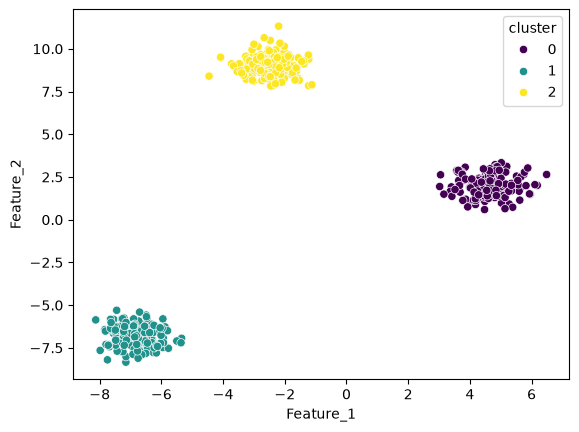

In [10]:
df['cluster'] = cluster_labels
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette='viridis')

In [11]:
from sklearn.datasets import make_moons
X, y_true = make_moons(n_samples=500,noise = 0.05,random_state=42)

In [12]:
from sklearn.cluster import KMeans, DBSCAN
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [14]:
kmeans =KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [15]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

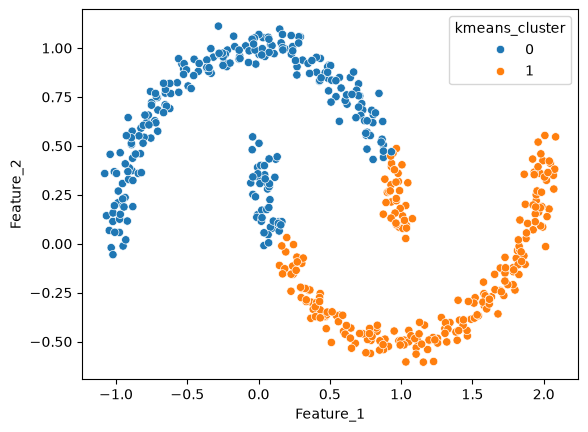

In [16]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['kmeans_cluster'],palette='tab10')

In [17]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [18]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

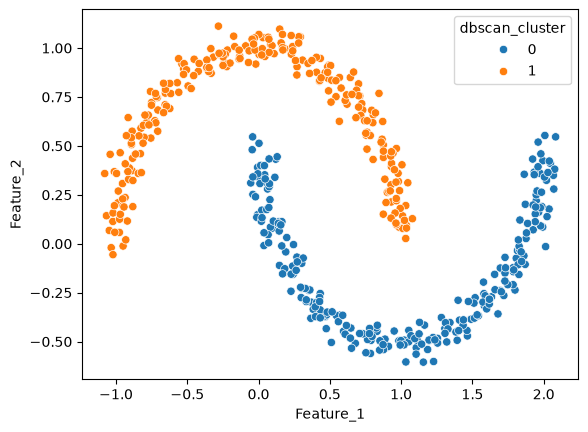

In [19]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')